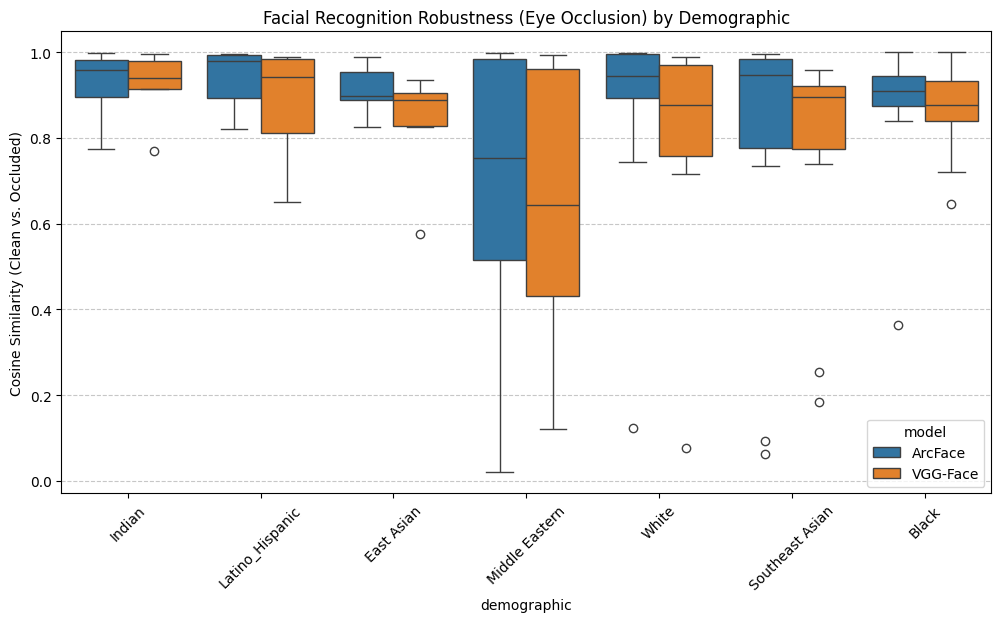

--- Statistical Significance Test (ANOVA) ---

Model: ArcFace
F-statistic: 1.0777
p-value: 3.8815e-01
Result: No statistically significant bias detected.

Model: VGG-Face
F-statistic: 1.1569
p-value: 3.4390e-01
Result: No statistically significant bias detected.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Load the data you just generated
df = pd.read_csv('results/bias_metrics.csv')

# 2. Visualization: Demographic vs. Similarity
plt.figure(figsize=(12, 6))
sns.boxplot(x='demographic', y='similarity', hue='model', data=df)
plt.title('Facial Recognition Robustness (Eye Occlusion) by Demographic')
plt.ylabel('Cosine Similarity (Clean vs. Occluded)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('results/bias_boxplot.png')
plt.show()

# 3. Statistical Testing (ANOVA)
print("--- Statistical Significance Test (ANOVA) ---")
for model in df['model'].unique():
    model_df = df[df['model'] == model]
    
    # Group similarity scores by demographic
    groups = [group['similarity'].values for name, group in model_df.groupby('demographic')]
    
    f_stat, p_val = stats.f_oneway(*groups)
    
    print(f"\nModel: {model}")
    print(f"F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_val:.4e}")
    
    if p_val < 0.05:
        print("Result: STATISTICALLY SIGNIFICANT BIAS DETECTED (p < 0.05)")
    else:
        print("Result: No statistically significant bias detected.")